Dataset: (5000, 15)

MODEL PERFORMANCE
               Model     MAE    RMSE      R2
0  Linear Regression  3.5645  4.4704  0.7100
1      Random Forest  3.5071  4.3456  0.7259

Best Model: Random Forest


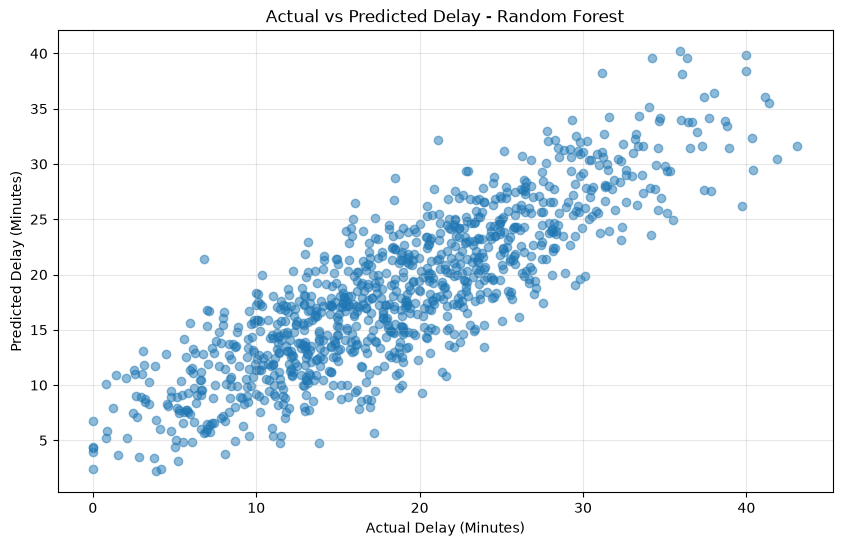


FEATURE IMPORTANCE
           Feature  Importance
7  weather_encoded      0.3114
3    station_delay      0.2244
6     is_peak_hour      0.1369
4   previous_delay      0.1367
0      distance_km      0.0915
2         rainfall      0.0398
1      temperature      0.0315
5   departure_hour      0.0278


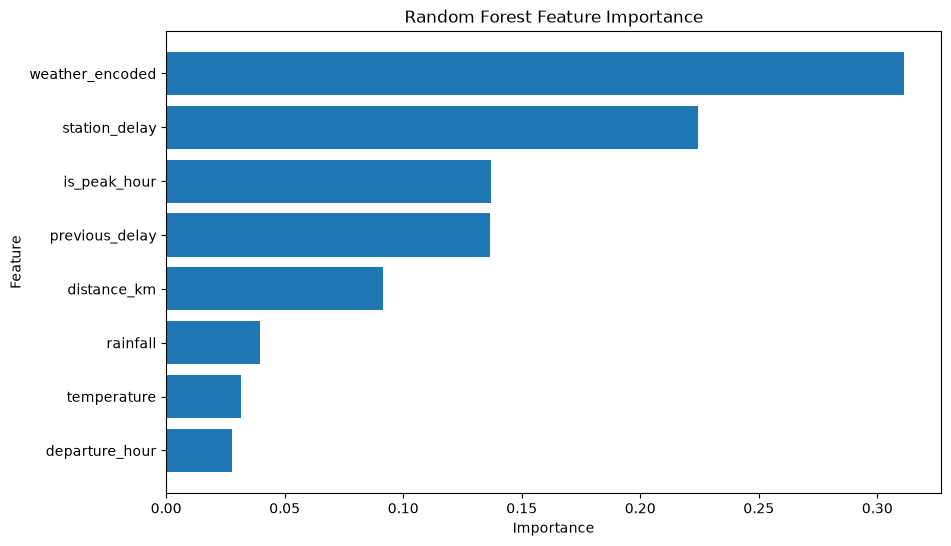


SAMPLE PREDICTIONS
   Actual_Delay  Predicted_Delay
0         29.84            19.61
1         17.55            13.34
2         10.04            12.35
3         13.62            16.14
4         16.76             8.74
5         14.08            10.45
6         14.12            13.12
7         33.00            28.89
8          8.72             4.92
9         23.54            21.33

Model saved:
../models/delay/delay_model.pkl

Predictions saved successfully!

🎉 04 DELAY PREDICTION COMPLETED!


In [10]:
# ============================================================
# RAILPULSE-AI
# DELAY PREDICTION - FINAL ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv("../data/processed/delay_processed.csv")

print("Dataset:", df.shape)


# ============================================================
# 2. CREATE REQUIRED FEATURES
# ============================================================

if "departure_hour" not in df.columns:

    df["departure_hour"] = pd.to_datetime(
        df["scheduled_departure"],
        format="%H:%M"
    ).dt.hour


if "is_peak_hour" not in df.columns:

    df["is_peak_hour"] = df["departure_hour"].apply(
        lambda x: 1
        if (7 <= x <= 10 or 17 <= x <= 21)
        else 0
    )


weather_mapping = {
    "Clear": 0,
    "Cloudy": 1,
    "Rain": 2,
    "Heavy Rain": 3,
    "Fog": 4
}

if "weather_encoded" not in df.columns:

    df["weather_encoded"] = df["weather"].map(
        weather_mapping
    )


# ============================================================
# 3. FEATURES & TARGET
# ============================================================

features = [
    "distance_km",
    "temperature",
    "rainfall",
    "station_delay",
    "previous_delay",
    "departure_hour",
    "is_peak_hour",
    "weather_encoded"
]

X = df[features]
y = df["delay_minutes"]


# ============================================================
# 4. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


# ============================================================
# 5. LINEAR REGRESSION
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)


# ============================================================
# 6. RANDOM FOREST
# ============================================================

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)


# ============================================================
# 7. METRICS
# ============================================================

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)


rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)


# ============================================================
# 8. MODEL COMPARISON
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest"
    ],

    "MAE": [
        linear_mae,
        rf_mae
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse
    ],

    "R2": [
        linear_r2,
        rf_r2
    ]
})


print("\n===================================")
print("MODEL PERFORMANCE")
print("===================================")

print(comparison.round(4))


# ============================================================
# 9. BEST MODEL
# ============================================================

if rf_r2 >= linear_r2:

    best_model = rf_model
    best_model_name = "Random Forest"
    best_predictions = rf_pred

else:

    best_model = linear_model
    best_model_name = "Linear Regression"
    best_predictions = linear_pred


print("\nBest Model:", best_model_name)


# ============================================================
# 10. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel("Actual Delay (Minutes)")
plt.ylabel("Predicted Delay (Minutes)")

plt.title(
    f"Actual vs Predicted Delay - {best_model_name}"
)

plt.grid(alpha=0.3)

plt.show()


# ============================================================
# 11. FEATURE IMPORTANCE
# ============================================================

if best_model_name == "Random Forest":

    importance = pd.DataFrame({

        "Feature": features,

        "Importance": rf_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\n===================================")
    print("FEATURE IMPORTANCE")
    print("===================================")

    print(importance.round(4))


    plt.figure(figsize=(10, 6))

    plt.barh(
        importance["Feature"],
        importance["Importance"]
    )

    plt.xlabel("Importance")

    plt.ylabel("Feature")

    plt.title(
        "Random Forest Feature Importance"
    )

    plt.gca().invert_yaxis()

    plt.show()


# ============================================================
# 12. SAMPLE PREDICTIONS
# ============================================================

prediction_table = pd.DataFrame({

    "Actual_Delay": y_test.values,

    "Predicted_Delay": best_predictions

})

print("\n===================================")
print("SAMPLE PREDICTIONS")
print("===================================")

print(
    prediction_table.head(10).round(2)
)


# ============================================================
# 13. SAVE MODEL
# ============================================================

model_path = "../models/delay/delay_model.pkl"

joblib.dump(
    best_model,
    model_path
)

print("\nModel saved:")
print(model_path)


# ============================================================
# 14. SAVE PREDICTIONS
# ============================================================

prediction_table.to_csv(
    "../data/processed/delay_predictions.csv",
    index=False
)

print("\nPredictions saved successfully!")

print("\n🎉 04 DELAY PREDICTION COMPLETED!")